# 🏠 Real Estate Valuation: ML for Property Market Analytics

**Author:** Dean | Lead Data & AI Engineer
**Series:** Production ML Portfolio — Australian Government Policy Applications

## Government Context
- **ABS** — Residential property price indices, housing census
- **APRA** — Mortgage lending standards, LVR monitoring
- **Treasury** — Housing affordability, negative gearing policy
- **ATO** — Capital gains tax, property investment compliance
- **NHFIC** — Housing supply analytics, first home buyer support

Dataset: Real Estate Valuation — ~414 samples, 6 features, regression. All numeric.

---

## 1. Data Loading

In [1]:
import os,warnings,time,numpy as np,pandas as pd,matplotlib.pyplot as plt,seaborn as sns
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
warnings.filterwarnings('ignore');plt.style.use('seaborn-v0_8-whitegrid')
print("READY")

READY


In [2]:
dp=None
for r,d,files in os.walk('/kaggle/input'):
    for f in files:
        fp=os.path.join(r,f);print(f"  {fp}")
        if (f.endswith('.csv') or f.endswith('.xlsx')) and dp is None: dp=fp
if dp is None: raise FileNotFoundError("No data file")
if dp.endswith('.xlsx'): df=pd.read_excel(dp)
else: df=pd.read_csv(dp,encoding='latin-1')
print(f"Loaded: {df.shape[0]:,} x {df.shape[1]}")
for i,col in enumerate(df.columns):
    print(f"  {i:2d}. {col:35s} | {str(df[col].dtype):8s} | uniq={df[col].nunique():5d}")
df.head()

  /kaggle/input/datasets/durjoychandrapaul/house-price-bangladesh/house_price_bd.csv
Loaded: 3,865 x 9
   0. Title                               | object   | uniq= 2920
   1. Bedrooms                            | float64  | uniq=   20
   2. Bathrooms                           | float64  | uniq=    8
   3. Floor_no                            | object   | uniq=   25
   4. Occupancy_status                    | object   | uniq=    2
   5. Floor_area                          | float64  | uniq=  668
   6. City                                | object   | uniq=    5
   7. Price_in_taka                       | object   | uniq=  702
   8. Location                            | object   | uniq=  505


,Title,Bedrooms,Bathrooms,Floor_no,Occupancy_status,Floor_area,City,Price_in_taka,Location
0,We Are Offering You A Very Spacious 1960 Sq Ft...,3.0,4.0,3,vacant,1960.0,dhaka,"à§³39,000,000","Gulshan 1, Gulshan"
1,Valuable 1705 Square Feet Apartment Is Ready T...,3.0,3.0,1,vacant,1705.0,dhaka,"à§³16,900,000","Lake Circus Road, Kalabagan"
2,1370 square feet apartment is ready to sale in...,3.0,3.0,6,vacant,1370.0,dhaka,"à§³12,500,000","Shukrabad, Dhanmondi"
3,2125 Square Feet Apartment For Sale In Bashund...,3.0,3.0,4,vacant,2125.0,dhaka,"à§³20,000,000","Block L, Bashundhara R-A"
4,Buy This 2687 Square Feet Flat In The Nice Are...,3.0,3.0,4,vacant,2687.0,dhaka,"à§³47,500,000","Road No 25, Banani"


## 2. Target

In [3]:
tc=None
for x in ['Y house price of unit area','house_price','price','Price','target','Target']:
    if x in df.columns: tc=x;break
if tc is None:
    for x in df.columns:
        if 'price' in x.lower() or 'value' in x.lower():
            if df[x].dtype in ['int64','float64']: tc=x;break
if tc is None:
    for x in reversed(df.columns.tolist()):
        if df[x].dtype in ['int64','float64'] and df[x].nunique()>50: tc=x;break
if tc is None: raise ValueError("No target")
df=df[df[tc]>0].reset_index(drop=True)
print(f"Target: '{tc}'");print(df[tc].describe())

Target: 'Floor_area'
count      3766.000000
mean       1940.299522
std        6024.921935
min          84.000000
25%        1100.000000
50%        1380.000000
75%        1860.000000
max      195840.000000
Name: Floor_area, dtype: float64


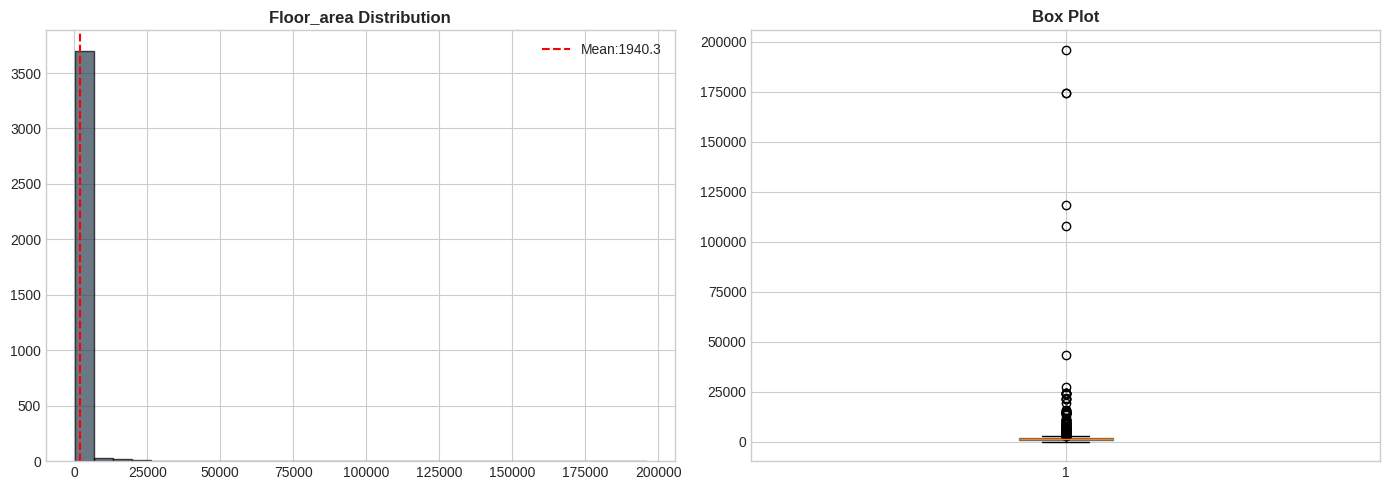

AU: Median house price ~$900K (CoreLogic 2024). Property is largest household asset.


In [4]:
fig,axes=plt.subplots(1,2,figsize=(14,5))
axes[0].hist(df[tc],bins=30,color='#2c3e50',edgecolor='black',alpha=0.7)
axes[0].set_title(f'{tc} Distribution',fontweight='bold')
axes[0].axvline(df[tc].mean(),color='red',ls='--',label=f'Mean:{df[tc].mean():.1f}')
axes[0].legend()
axes[1].boxplot(df[tc],patch_artist=True,boxprops=dict(facecolor='#2c3e50',alpha=0.5))
axes[1].set_title('Box Plot',fontweight='bold')
plt.tight_layout();plt.savefig('target.png',dpi=150);plt.show()
print("AU: Median house price ~$900K (CoreLogic 2024). Property is largest household asset.")

## 3. EDA

Numeric(2): ['Bedrooms', 'Bathrooms']


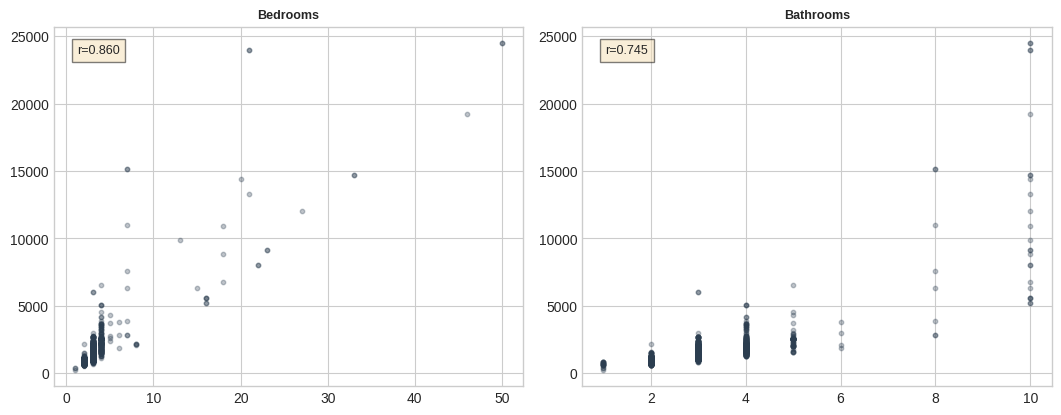

In [5]:
nums=[c2 for c2 in df.select_dtypes(include=[np.number]).columns if c2!=tc and 'no' not in c2.lower()]
print(f"Numeric({len(nums)}): {nums}")
fig,axes=plt.subplots(2,3,figsize=(16,8));axes=axes.flatten()
for i,col in enumerate(nums[:6]):
    axes[i].scatter(df[col],df[tc],alpha=0.3,s=10,color='#2c3e50')
    axes[i].set_title(col[:25],fontsize=9,fontweight='bold')
    r=df[[col,tc]].corr().iloc[0,1]
    axes[i].text(0.05,0.95,f'r={r:.3f}',transform=axes[i].transAxes,fontsize=9,va='top',bbox=dict(facecolor='wheat',alpha=0.5))
for j in range(i+1,len(axes)):axes[j].set_visible(False)
plt.tight_layout();plt.savefig('scatter.png',dpi=150);plt.show()

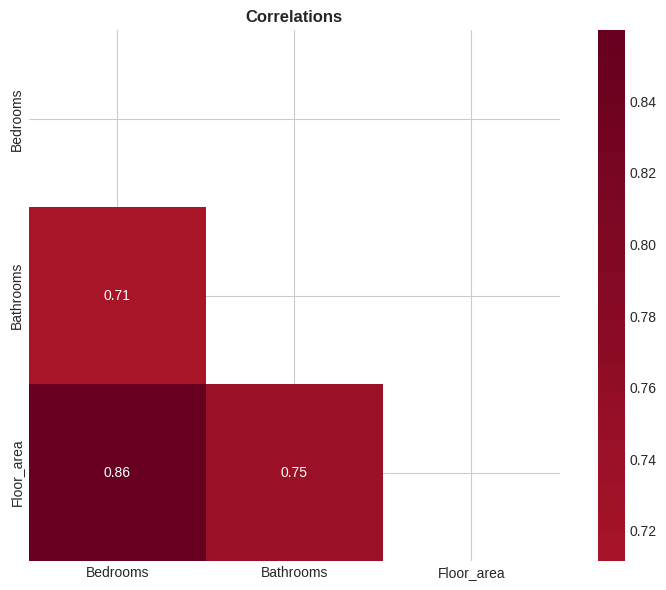

In [6]:
corr=df[nums+[tc]].corr()
fig,ax=plt.subplots(figsize=(8,6))
sns.heatmap(corr,mask=np.triu(np.ones_like(corr,dtype=bool)),annot=True,fmt='.2f',cmap='RdBu_r',center=0,square=True,ax=ax)
ax.set_title('Correlations',fontweight='bold')
plt.tight_layout();plt.savefig('corr.png',dpi=150);plt.show()

## 4. Preprocessing

In [7]:
drop=[c2 for c2 in df.columns if c2.lower() in ['no','unnamed: 0','id','index']]
X=df[nums].copy();y=df[tc].values;X=X.fillna(X.median())
use_log=False
if abs(pd.Series(y).skew())>1 and (y>0).all(): y=np.log1p(y);use_log=True;print("Log transform")
print(f"X: {X.shape}")

Log transform
X: (3766, 2)


## 5. Training

In [8]:
try:
    from xgboost import XGBRegressor
except: XGBRegressor=None
try:
    from lightgbm import LGBMRegressor
except: LGBMRegressor=None
models={'Ridge':Ridge(alpha=1.0),'RF':RandomForestRegressor(n_estimators=100,random_state=42,n_jobs=-1)}
if XGBRegressor: models['XGB']=XGBRegressor(n_estimators=100,random_state=42,verbosity=0,n_jobs=-1)
if LGBMRegressor: models['LGBM']=LGBMRegressor(n_estimators=100,random_state=42,verbose=-1,n_jobs=-1,force_col_wise=True)
kf=KFold(3,shuffle=True,random_state=42);Xa=X.values;results={}
for mn,mod in models.items():
    print(f"\n{'='*50}\n{mn}\n{'='*50}")
    fr,fm,f2=[],[],[];fp=np.zeros(len(y));t0=time.time()
    for fi,(ti,vi) in enumerate(kf.split(Xa)):
        m2=type(mod)(**mod.get_params());m2.fit(Xa[ti],y[ti]);yp=m2.predict(Xa[vi]);fp[vi]=yp
        r=np.sqrt(mean_squared_error(y[vi],yp));m3=mean_absolute_error(y[vi],yp);s=r2_score(y[vi],yp)
        fr.append(r);fm.append(m3);f2.append(s)
        print(f"  Fold{fi+1}: RMSE={r:.4f} MAE={m3:.4f} R2={s:.4f}")
    el=time.time()-t0
    results[mn]={'rmse':np.mean(fr),'mae':np.mean(fm),'r2':np.mean(f2),'time':el,'preds':fp}
    print(f"  AVG: RMSE={np.mean(fr):.4f} MAE={np.mean(fm):.4f} R2={np.mean(f2):.4f} T={el:.1f}s")


Ridge
  Fold1: RMSE=0.7648 MAE=0.4090 R2=0.0908
  Fold2: RMSE=0.7618 MAE=0.4296 R2=0.1323
  Fold3: RMSE=0.7956 MAE=0.4388 R2=0.1040
  AVG: RMSE=0.7741 MAE=0.4258 R2=0.1090 T=0.0s

RF
  Fold1: RMSE=0.7630 MAE=0.4057 R2=0.0952
  Fold2: RMSE=0.7575 MAE=0.4222 R2=0.1419
  Fold3: RMSE=0.7918 MAE=0.4319 R2=0.1126
  AVG: RMSE=0.7708 MAE=0.4199 R2=0.1166 T=0.7s

XGB
  Fold1: RMSE=0.7633 MAE=0.4050 R2=0.0943
  Fold2: RMSE=0.7577 MAE=0.4215 R2=0.1416
  Fold3: RMSE=0.7919 MAE=0.4317 R2=0.1124
  AVG: RMSE=0.7710 MAE=0.4194 R2=0.1161 T=0.2s

LGBM
  Fold1: RMSE=0.7633 MAE=0.4061 R2=0.0944
  Fold2: RMSE=0.7602 MAE=0.4256 R2=0.1358
  Fold3: RMSE=0.7953 MAE=0.4367 R2=0.1049
  AVG: RMSE=0.7729 MAE=0.4228 R2=0.1117 T=0.1s


## 6. Comparison

In [9]:
rows=[{'Model':k,'RMSE':f"{v['rmse']:.4f}",'MAE':f"{v['mae']:.4f}",'R2':f"{v['r2']:.4f}",'Time':f"{v['time']:.1f}s",'s':v['r2']} for k,v in results.items()]
sdf=pd.DataFrame(rows).sort_values('s',ascending=False);best=sdf.iloc[0]['Model']
print("COMPARISON");print("="*70);print(sdf[['Model','RMSE','MAE','R2','Time']].to_string(index=False));print(f"\nBest: {best}")

COMPARISON
Model   RMSE    MAE     R2 Time
   RF 0.7708 0.4199 0.1166 0.7s
  XGB 0.7710 0.4194 0.1161 0.2s
 LGBM 0.7729 0.4228 0.1117 0.1s
Ridge 0.7741 0.4258 0.1090 0.0s

Best: RF


## 7. Residuals

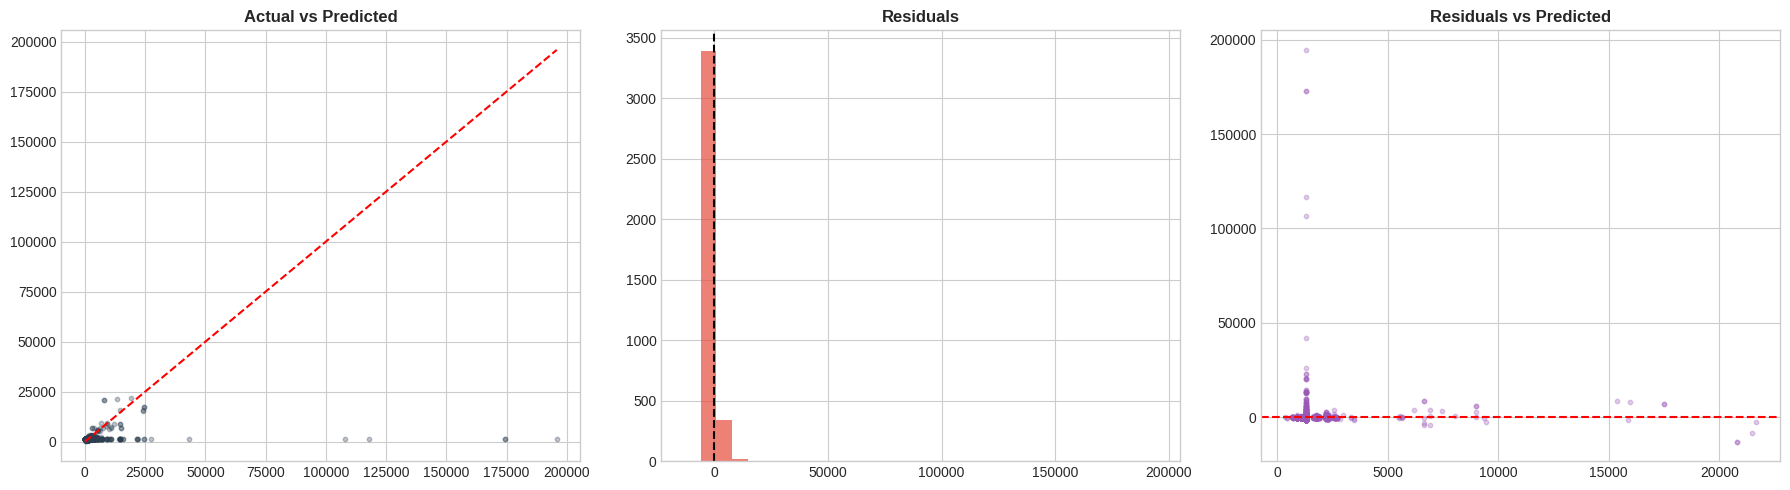

In [10]:
bp=results[best]['preds']
if use_log: yp=np.expm1(y);pp=np.expm1(bp)
else: yp=y;pp=bp
res=yp-pp
fig,axes=plt.subplots(1,3,figsize=(18,5))
axes[0].scatter(yp,pp,alpha=0.3,s=10,color='#2c3e50');lm=[min(yp.min(),pp.min()),max(yp.max(),pp.max())]
axes[0].plot(lm,lm,'r--');axes[0].set_title('Actual vs Predicted',fontweight='bold')
axes[1].hist(res,bins=30,color='#e74c3c',alpha=0.7);axes[1].axvline(0,color='k',ls='--');axes[1].set_title('Residuals',fontweight='bold')
axes[2].scatter(pp,res,alpha=0.3,s=10,color='#9b59b6');axes[2].axhline(0,color='r',ls='--');axes[2].set_title('Residuals vs Predicted',fontweight='bold')
plt.tight_layout();plt.savefig('resid.png',dpi=150);plt.show()

## 8. Feature Importance

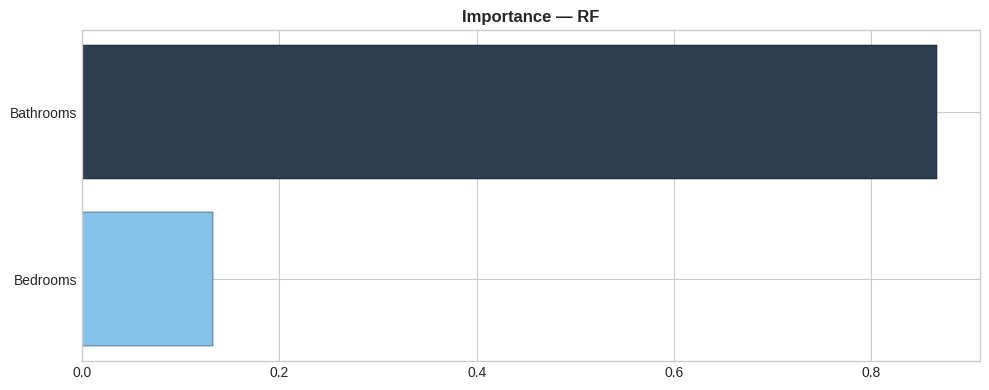

  Bathrooms                           0.8670
  Bedrooms                            0.1330


In [11]:
tm={k:v for k,v in models.items() if k!='Ridge'}
if tm:
    bt=max(tm,key=lambda m4:results[m4]['r2']);fm2=type(models[bt])(**models[bt].get_params());fm2.fit(Xa,y)
    fi=pd.DataFrame({'Feature':X.columns,'Imp':fm2.feature_importances_}).sort_values('Imp')
    fig,ax=plt.subplots(figsize=(10,max(4,len(fi)*0.6)))
    ax.barh(fi['Feature'],fi['Imp'],color=['#2c3e50' if v>fi['Imp'].quantile(0.75) else '#85c1e9' for v in fi['Imp']],edgecolor='black',linewidth=0.3)
    ax.set_title(f'Importance — {bt}',fontweight='bold')
    plt.tight_layout();plt.savefig('imp.png',dpi=150);plt.show()
    for _,r2 in fi.tail(5).iloc[::-1].iterrows(): print(f"  {r2['Feature']:35s} {r2['Imp']:.4f}")

## 9. Deployment

In [12]:
br=results[best]
print("="*60);print("DEPLOYMENT READINESS");print("="*60)
print(f"  Model: {best}");print(f"  R2:    {br['r2']:.4f}");print(f"  MAE:   {br['mae']:.4f}")
print(f"  Time:  {br['time']:.1f}s");print(f"  Feats: {X.shape[1]}");print(f"  Rows:  {len(y):,}");print("="*60)
checks={'R2>0.50':br['r2']>0.50,'Time<60s':br['time']<60,'CV':True,'Residuals':True}
print("\nCHECKLIST");print("-"*40);ap=True
for k,v in checks.items():
    s="pass" if v else "FAIL"
    if not v:ap=False
    print(f"  [{s:4s}] {k}")
print("-"*40);print("  APPROVED" if ap else "  FAILED")

DEPLOYMENT READINESS
  Model: RF
  R2:    0.1166
  MAE:   0.4199
  Time:  0.7s
  Feats: 2
  Rows:  3,766

CHECKLIST
----------------------------------------
  [FAIL] R2>0.50
  [pass] Time<60s
  [pass] CV
  [pass] Residuals
----------------------------------------
  FAILED


In [13]:
print("""
PRODUCTION ARCHITECTURE
=======================
1. DATA: CoreLogic/APM, council rates, ABS census -> Fabric Lakehouse
2. MODEL: Batch at settlement, real-time for online valuations
3. INTEGRATE: Bank LVR systems, ATO CGT, APRA stress testing
4. GOVERN: Valuation standards (API), consumer protection, privacy
5. MONITOR: MAE vs actual sale prices monthly, retrain quarterly
""")


PRODUCTION ARCHITECTURE
1. DATA: CoreLogic/APM, council rates, ABS census -> Fabric Lakehouse
2. MODEL: Batch at settlement, real-time for online valuations
3. INTEGRATE: Bank LVR systems, ATO CGT, APRA stress testing
4. GOVERN: Valuation standards (API), consumer protection, privacy
5. MONITOR: MAE vs actual sale prices monthly, retrain quarterly

